# CS659 Coin Counter — YOLO Model Testing & Hyperparameter Tuning

This notebook covers the full evaluation workflow for the trained YOLO coin detector.

**What this notebook does:**
1. Install packages
2. Download the Roboflow dataset
3. Load `best.pt`
4. Run standard validation (baseline) — generates all paper plots
5. **Hyperparameter tuning** — sweep confidence and IoU thresholds at inference time
6. Display the paper plots (confusion matrix, F1, recall, PR curves)
7. Run sample predictions with the best inference thresholds
8. Save everything to Google Drive (optional)

> **Note:** Upload `best.pt` to the Colab session before running.
>
> **About the sweep:** YOLO's `val()` computes mAP by internally sweeping confidence,
> so passing `conf` to `val()` affects NMS postprocessing but not the mAP curve itself.
> The sweep here identifies the best **inference-time** threshold for practical use
> (i.e. what conf/iou to use when running `predict()`), evaluated by F1 score on the
> validation set at that fixed threshold — which is the quantity that actually matters
> when deploying the model.

---
## 1) Install packages

In [ ]:
!nvidia-smi
!pip -q install -U ultralytics roboflow

Mon May 11 23:16:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## 2) Download the dataset

Uses the same Roboflow project and version as training.

In [ ]:
from roboflow import Roboflow
import os, yaml

ROBOFLOW_API_KEY = "GETYOUROWN"  # replace if key has changed
WORKSPACE  = "atathamuscoinsdataset"
PROJECT    = "u.s.-coins-dataset-a.tatham"
VERSION    = 20

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
dataset = rf.workspace(WORKSPACE).project(PROJECT).version(VERSION).download("yolov8")

data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path) as f:
    data_yaml = yaml.safe_load(f)

print("Dataset location:", dataset.location)
print("Classes:", data_yaml.get("names"))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to U.S.-Coins-Dataset---A.Tatham-20 in yolov8:: 100%|██████████| 4796/4796 [00:00<00:00, 6642.61it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset location: /content/U.S.-Coins-Dataset---A.Tatham-20
Classes: ['Dime', 'Nickel', 'Penny', 'Quarter']


---
## 3) Load the trained model

In [ ]:
from ultralytics import YOLO
import torch

MODEL_PATH = "best.pt"  # must be uploaded to the Colab session
DEVICE     = 0 if torch.cuda.is_available() else "cpu"

model = YOLO(MODEL_PATH)
print(f"Model loaded. Running on: {'GPU' if DEVICE == 0 else 'CPU'}")

Model loaded. Running on: GPU


---
## 4) Baseline validation

Runs YOLO's built-in validation with default thresholds.
This generates all the standard diagnostic plots (confusion matrix, F1 curve,
recall curve, PR curve) used in the paper.

We pass `save_dir` explicitly so the output folder is always
`coin_counter_eval/baseline_val` regardless of whether Colab would
otherwise auto-increment it to `baseline_val2`, `baseline_val3`, etc.

In [ ]:
val_metrics = model.val(
    data=data_yaml_path,
    split="val",
    imgsz=640,
    device=DEVICE,
    plots=True,
    save_dir="coin_counter_eval/baseline_val",
    verbose=False,
)

# Store the plot directory so downstream cells always use the right path
BASELINE_PLOT_DIR = "coin_counter_eval/baseline_val"
print(f"Baseline plots saved to: {BASELINE_PLOT_DIR}")
print(f"Files: {os.listdir(BASELINE_PLOT_DIR)}")

def print_metrics(metrics, label):
    """Print the four key detection metrics in a readable block."""
    b = metrics.box
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(f"  Precision (mean):   {b.mp:.4f}")
    print(f"  Recall (mean):      {b.mr:.4f}")
    print(f"  mAP@0.5:            {b.map50:.4f}")
    print(f"  mAP@0.5:0.95:       {b.map:.4f}")
    print()

print_metrics(val_metrics, "Baseline Validation (default thresholds)")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1316.5±592.1 MB/s, size: 61.0 KB)
val: Scanning /content/U.S.-Coins-Dataset---A.Tatham-20/valid/labels... 260 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 260/260 1.2Kit/s 0.2s
val: New cache created: /content/U.S.-Coins-Dataset---A.Tatham-20/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.4it/s 12.5s
                   all        260       8876      0.952      0.889        0.9      0.701
Speed: 2.7ms preprocess, 4.8ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/coin_counter_eval/baseline_val
Baseline plots saved to: coin_counter_eval/baseline_val
Files: ['val_batch1_labels.jpg', 'val_batch2_labels.jpg', 'BoxP_curve.png', 'val_batch0_labels.jpg', 'val_

---
## 5) Hyperparameter tuning — confidence & IoU threshold sweep

This sweep finds the best **inference-time** thresholds — i.e., what `conf` and `iou`
to use when running `model.predict()` on a new image.

**How it works:** For each conf/iou pair, we run the model on every validation image
at that fixed threshold, then compute precision, recall, and F1 directly from the
resulting detections vs. ground-truth boxes. This gives a fair per-threshold comparison.

**Why not use `val()` for the sweep?**
YOLO's `val()` always rebuilds the full precision-recall curve internally by sweeping
confidence from 0 to 1, so passing a `conf` argument to it does not change the reported
mAP — it only affects NMS. The approach below directly measures performance at each
fixed threshold, which is the quantity that matters in practice.

**Parameters swept:**
- `conf` — minimum confidence to keep a detection
- `iou` — NMS overlap threshold (controls suppression of duplicate boxes)

In [ ]:
import itertools
import pandas as pd
import glob
import numpy as np

# --- Grid definition ---
CONF_VALUES = [0.25, 0.35, 0.40, 0.50, 0.60]
IOU_VALUES  = [0.40, 0.50, 0.60, 0.70]

val_image_paths = sorted(glob.glob(os.path.join(dataset.location, "valid", "images", "*")))
val_label_dir   = os.path.join(dataset.location, "valid", "labels")

def load_gt_boxes(label_path, img_w=640, img_h=640):
    """Load YOLO-format ground-truth boxes for one image."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])
            x1 = (cx - w / 2) * img_w
            y1 = (cy - h / 2) * img_h
            x2 = (cx + w / 2) * img_w
            y2 = (cy + h / 2) * img_h
            boxes.append((cls, x1, y1, x2, y2))
    return boxes

def box_iou(b1, b2):
    """Compute IoU between two boxes (x1,y1,x2,y2)."""
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def evaluate_at_threshold(conf, iou_thresh, match_iou=0.5):
    """
    Run model.predict() on the full validation set at (conf, iou_thresh),
    then compute micro-averaged precision, recall, and F1 against GT boxes.
    match_iou: IoU threshold used to decide if a prediction matches a GT box.
    """
    tp = fp = fn = 0
    for img_path in val_image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(val_label_dir, stem + ".txt")
        gt_boxes = load_gt_boxes(label_path)

        results = model.predict(
            source=img_path,
            imgsz=640,
            conf=conf,
            iou=iou_thresh,
            device=DEVICE,
            verbose=False,
            save=False,
        )
        preds = []
        for r in results:
            if r.boxes is not None:
                for box in r.boxes:
                    cls = int(box.cls.item())
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    preds.append((cls, x1, y1, x2, y2))

        matched_gt = set()
        for pcls, px1, py1, px2, py2 in preds:
            matched = False
            for gi, (gcls, gx1, gy1, gx2, gy2) in enumerate(gt_boxes):
                if gi in matched_gt or gcls != pcls:
                    continue
                if box_iou((px1,py1,px2,py2),(gx1,gy1,gx2,gy2)) >= match_iou:
                    tp += 1
                    matched_gt.add(gi)
                    matched = True
                    break
            if not matched:
                fp += 1
        fn += len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

# --- Run the sweep ---
results_list = []
print("Running inference-time threshold sweep...")
print(f"{'Conf':>6}  {'IoU':>6}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print("-" * 48)

for conf, iou in itertools.product(CONF_VALUES, IOU_VALUES):
    prec, rec, f1 = evaluate_at_threshold(conf, iou)
    results_list.append(dict(conf=conf, iou=iou, precision=prec, recall=rec, f1=f1))
    print(f"{conf:>6.2f}  {iou:>6.2f}  {prec:>10.4f}  {rec:>8.4f}  {f1:>8.4f}")

sweep_df = pd.DataFrame(results_list)
print("\nSweep complete.")

Running inference-time threshold sweep...
  Conf     IoU   Precision    Recall        F1
------------------------------------------------
  0.25    0.40      0.9472    0.8945    0.9201
  0.25    0.50      0.9471    0.8949    0.9202
  0.25    0.60      0.9467    0.8950    0.9201
  0.25    0.70      0.9455    0.8950    0.9196
  0.35    0.40      0.9538    0.8925    0.9221
  0.35    0.50      0.9537    0.8926    0.9221
  0.35    0.60      0.9534    0.8926    0.9220
  0.35    0.70      0.9529    0.8927    0.9218
  0.40    0.40      0.9563    0.8904    0.9222
  0.40    0.50      0.9562    0.8905    0.9222
  0.40    0.60      0.9560    0.8905    0.9221
  0.40    0.70      0.9554    0.8906    0.9219
  0.50    0.40      0.9645    0.8826    0.9218
  0.50    0.50      0.9645    0.8827    0.9218
  0.50    0.60      0.9644    0.8827    0.9218
  0.50    0.70      0.9641    0.8828    0.9217
  0.60    0.40      0.9729    0.8659    0.9163
  0.60    0.50      0.9729    0.8660    0.9164
  0.60    0.60  

In [ ]:
# --- Best configuration by F1 ---
best_row  = sweep_df.loc[sweep_df["f1"].idxmax()]
BEST_CONF = float(best_row["conf"])
BEST_IOU  = float(best_row["iou"])

print("\n" + "="*50)
print("  BEST CONFIGURATION (by F1 score)")
print("="*50)
print(f"  conf threshold : {BEST_CONF}")
print(f"  iou  threshold : {BEST_IOU}")
print(f"  Precision      : {best_row['precision']:.4f}")
print(f"  Recall         : {best_row['recall']:.4f}")
print(f"  F1             : {best_row['f1']:.4f}")
print()
print("Full sweep table (sorted by F1):")
print(sweep_df.sort_values("f1", ascending=False).to_string(index=False))


  BEST CONFIGURATION (by F1 score)
  conf threshold : 0.4
  iou  threshold : 0.5
  Precision      : 0.9562
  Recall         : 0.8905
  F1             : 0.9222

Full sweep table (sorted by F1):
 conf  iou  precision   recall       f1
 0.40  0.5   0.956206 0.890491 0.922179
 0.40  0.4   0.956317 0.890379 0.922170
 0.35  0.5   0.953659 0.892632 0.922137
 0.35  0.4   0.953768 0.892519 0.922128
 0.40  0.6   0.955975 0.890491 0.922072
 0.35  0.6   0.953430 0.892632 0.922030
 0.40  0.7   0.955402 0.890604 0.921866
 0.35  0.7   0.952862 0.892744 0.921824
 0.50  0.5   0.964545 0.882717 0.921819
 0.50  0.6   0.964426 0.882717 0.921765
 0.50  0.4   0.964541 0.882605 0.921756
 0.50  0.7   0.964075 0.882830 0.921665
 0.25  0.5   0.947061 0.894885 0.920234
 0.25  0.6   0.946729 0.894998 0.920137
 0.25  0.4   0.947155 0.894547 0.920100
 0.25  0.7   0.945489 0.894998 0.919551
 0.60  0.5   0.972915 0.866043 0.916374
 0.60  0.6   0.972915 0.866043 0.916374
 0.60  0.7   0.972792 0.866043 0.916319
 0.60 

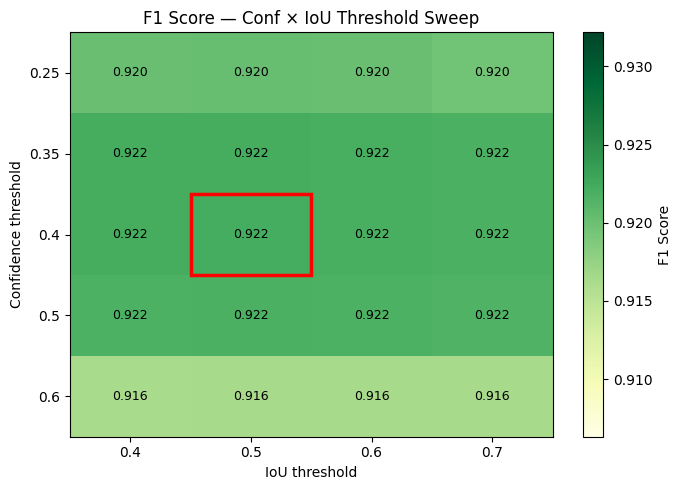

Saved: coin_counter_eval/threshold_heatmap.png


In [ ]:
import matplotlib.pyplot as plt

pivot = sweep_df.pivot(index="conf", columns="iou", values="f1")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto",
               vmin=pivot.values.min() - 0.01,
               vmax=pivot.values.max() + 0.01)

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([str(v) for v in pivot.columns])
ax.set_yticklabels([str(v) for v in pivot.index])
ax.set_xlabel("IoU threshold")
ax.set_ylabel("Confidence threshold")
ax.set_title("F1 Score — Conf × IoU Threshold Sweep")

# Highlight the best cell with a red border
best_i = list(pivot.index).index(BEST_CONF)
best_j = list(pivot.columns).index(BEST_IOU)
ax.add_patch(plt.Rectangle((best_j - 0.5, best_i - 0.5), 1, 1,
                            fill=False, edgecolor="red", linewidth=2.5))

for i, j in itertools.product(range(len(pivot.index)), range(len(pivot.columns))):
    val = pivot.values[i, j]
    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, label="F1 Score")
plt.tight_layout()
os.makedirs("coin_counter_eval", exist_ok=True)
plt.savefig("coin_counter_eval/threshold_heatmap.png", dpi=150)
plt.show()
print("Saved: coin_counter_eval/threshold_heatmap.png")

---
## 6) Display the paper plots

These are the standard diagnostic plots generated by the baseline validation run:
confusion matrix, F1-confidence curve, recall-confidence curve, and PR curve.
These are the same figures referenced in the paper.

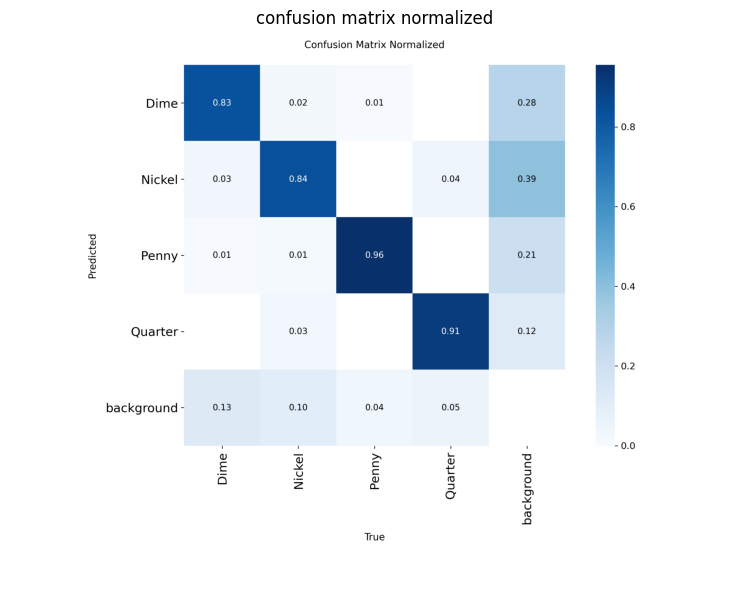

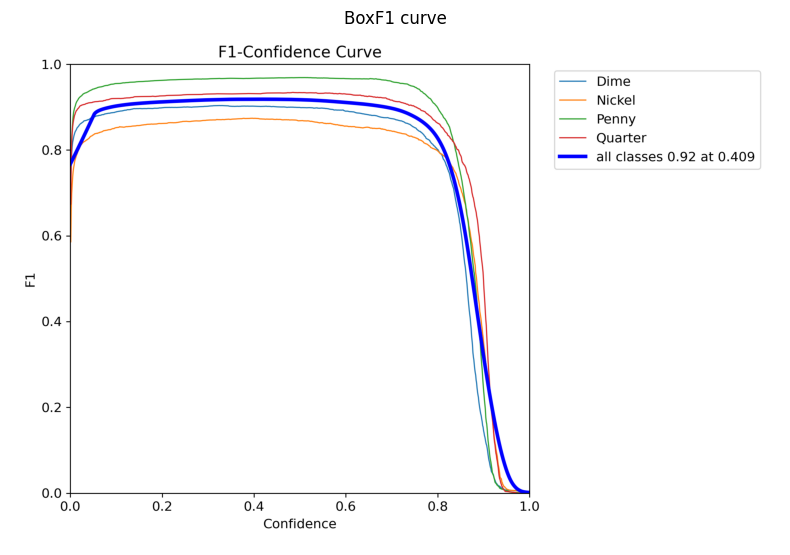

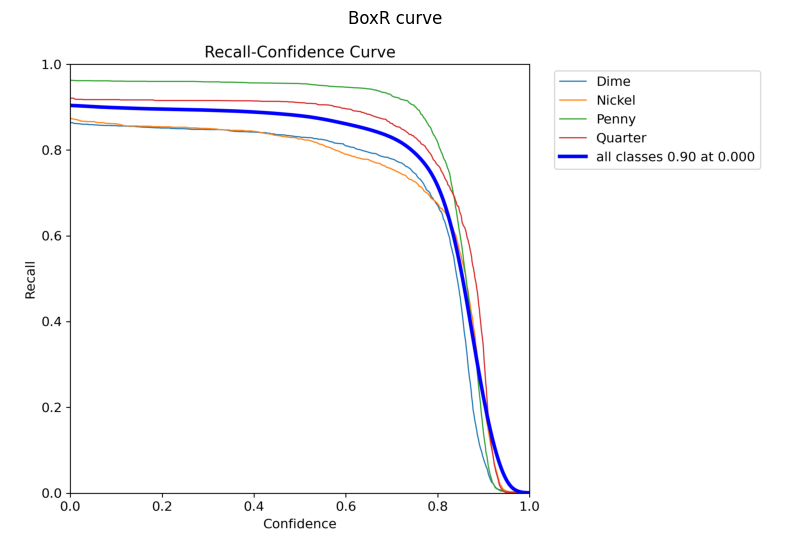

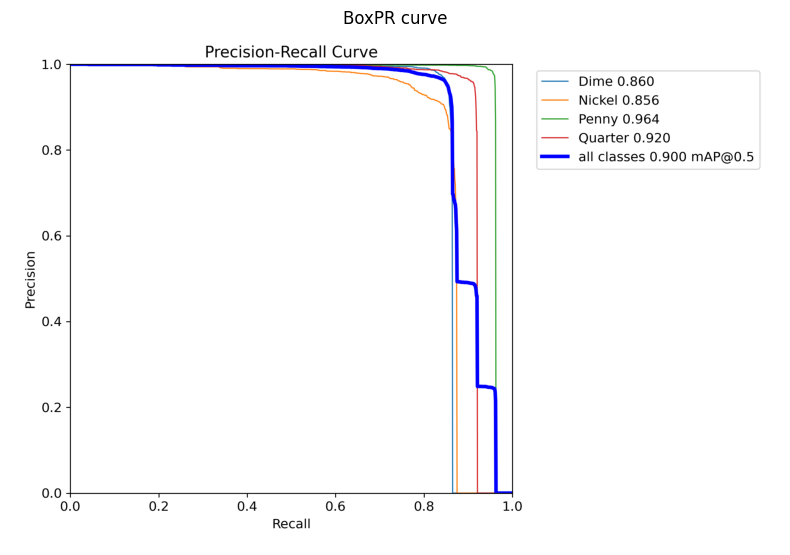

In [ ]:
from PIL import Image

# These are the filenames Ultralytics actually writes for YOLOv8 box detection
PLOT_NAMES = [
    "confusion_matrix_normalized.png",
    "BoxF1_curve.png",
    "BoxR_curve.png",
    "BoxPR_curve.png",
]

for name in PLOT_NAMES:
    path = os.path.join(BASELINE_PLOT_DIR, name)
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(name.replace(".png", "").replace("_", " "))
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        # List what is actually there to help debug
        print(f"Not found: {path}")
        if os.path.isdir(BASELINE_PLOT_DIR):
            print(f"  Files in {BASELINE_PLOT_DIR}: {sorted(os.listdir(BASELINE_PLOT_DIR))}")
        else:
            print(f"  Directory does not exist: {BASELINE_PLOT_DIR}")

---
## 7) Sample predictions with best thresholds

Runs inference on 5 random validation images using the best conf/iou
found in the sweep and displays the annotated results.

In [ ]:
import random

sample_paths = random.sample(val_image_paths, k=min(5, len(val_image_paths)))

model.predict(
    source=sample_paths,
    imgsz=640,
    conf=BEST_CONF,
    iou=BEST_IOU,
    save=True,
    save_dir="coin_counter_eval/sample_preds",
    verbose=True,
)

pred_dir = "coin_counter_eval/sample_preds"
for img_path in sample_paths:
    saved = os.path.join(pred_dir, os.path.basename(img_path))
    if os.path.exists(saved):
        img = Image.open(saved)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(os.path.basename(saved))
        plt.axis("off")
        plt.tight_layout()
        plt.show()


0: 640x640 15 Dimes, 7.2ms
1: 640x640 15 Dimes, 5 Pennys, 7.2ms
2: 640x640 18 Dimes, 15 Nickels, 3 Pennys, 7.2ms
3: 640x640 8 Pennys, 8 Quarters, 7.2ms
4: 640x640 8 Pennys, 8 Quarters, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


---
## 8) Save outputs to Google Drive (optional)

In [ ]:
# Uncomment to save everything to Drive
# from google.colab import drive
# import shutil
# drive.mount('/content/drive')
# out = "/content/drive/MyDrive/CoinCounterEval"
# os.makedirs(out, exist_ok=True)
# shutil.copytree("coin_counter_eval", os.path.join(out, "coin_counter_eval"), dirs_exist_ok=True)
# print("Saved to", out)